# ManiSkill Baseline Analysis Notebook

本 notebook 面向当前 baseline 项目，覆盖：

1. 训练曲线分析（`metrics.csv`）
2. 实验对比汇总（`summary.json`）
3. 配置-结果联动分析（`resolved_config.yaml` + summary）
4. ManiSkill demonstration `.npz` 数据健康检查

设计原则：
- 在数据路径未确定时也能运行
- 读取失败不阻塞后续单元
- 后续只需修改配置区路径即可切换到真实数据

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 100)

# ---- 配置区：后续接入真实 ManiSkill 数据时，主要改这里 ----
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_GLOB = "results/full_baseline_synthetic_smoke*"
DEMO_NPZ_PATH = ""  # 例如: "data/pickcube_state_demo.npz" 或绝对路径

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"RESULTS_GLOB = {RESULTS_GLOB}")
print(f"DEMO_NPZ_PATH = {DEMO_NPZ_PATH!r}")

PROJECT_ROOT = /Users/kiki/Documents/Codex/2026-04-22-files-mentioned-by-the-user-proposal/full_baseline_project
RESULTS_GLOB = results/full_baseline_synthetic_smoke*
DEMO_NPZ_PATH = ''


In [2]:
def as_path(path_str: str) -> Path | None:
    if not path_str:
        return None
    p = Path(path_str)
    return p if p.is_absolute() else (PROJECT_ROOT / p)


def safe_read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except (OSError, json.JSONDecodeError) as exc:
        print(f"[WARN] 无法读取 JSON: {path} -> {exc}")
        return None


def safe_read_yaml(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with path.open("r", encoding="utf-8") as f:
            data = yaml.safe_load(f)
        return data if isinstance(data, dict) else None
    except (OSError, yaml.YAMLError) as exc:
        print(f"[WARN] 无法读取 YAML: {path} -> {exc}")
        return None


def safe_read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except (OSError, pd.errors.EmptyDataError, pd.errors.ParserError) as exc:
        print(f"[WARN] 无法读取 CSV: {path} -> {exc}")
        return None


def discover_result_dirs() -> list[Path]:
    dirs = sorted((PROJECT_ROOT).glob(RESULTS_GLOB))
    return [d for d in dirs if d.is_dir()]


def build_experiment_table() -> pd.DataFrame:
    rows: list[dict] = []
    for exp_dir in discover_result_dirs():
        summary = safe_read_json(exp_dir / "summary.json")
        config = safe_read_yaml(exp_dir / "resolved_config.yaml")
        if summary is None:
            continue

        final_metrics = summary.get("final_metrics", {}) if isinstance(summary, dict) else {}
        training_cfg = (config or {}).get("training", {})
        data_cfg = (config or {}).get("data", {})
        model_cfg = (config or {}).get("model", {})

        rows.append(
            {
                "exp_name": exp_dir.name,
                "exp_dir": str(exp_dir),
                "epochs": summary.get("epochs"),
                "train_dataset_size": summary.get("train_dataset_size"),
                "val_dataset_size": summary.get("val_dataset_size"),
                "total_training_time_sec": summary.get("total_training_time_sec"),
                "final_train_mse": final_metrics.get("train_mse"),
                "final_val_mse": final_metrics.get("val_mse"),
                "final_val_success_rate": final_metrics.get("val_success_rate"),
                "final_val_cumulative_reward": final_metrics.get("val_cumulative_reward"),
                "sequence_length": data_cfg.get("sequence_length"),
                "stride": data_cfg.get("stride"),
                "noise_std": data_cfg.get("noise_std"),
                "hidden_dim": model_cfg.get("hidden_dim"),
                "num_layers": model_cfg.get("num_layers"),
                "num_heads": model_cfg.get("num_heads"),
                "learning_rate": training_cfg.get("learning_rate"),
                "batch_size": training_cfg.get("batch_size"),
            }
        )

    return pd.DataFrame(rows)


def pick_best_experiment(df: pd.DataFrame) -> pd.Series | None:
    if df.empty:
        return None

    if "final_val_success_rate" in df.columns and df["final_val_success_rate"].notna().any():
        ranked = df.sort_values(
            by=["final_val_success_rate", "final_val_mse"],
            ascending=[False, True],
            na_position="last",
        )
        return ranked.iloc[0]

    if "final_val_mse" in df.columns and df["final_val_mse"].notna().any():
        ranked = df.sort_values(by=["final_val_mse"], ascending=[True], na_position="last")
        return ranked.iloc[0]

    return df.iloc[0]

## 训练曲线（metrics.csv）

发现结果目录数量: 1
使用最新实验目录: /Users/kiki/Documents/Codex/2026-04-22-files-mentioned-by-the-user-proposal/full_baseline_project/results/full_baseline_synthetic_smoke


,epoch,train_mse,train_success_rate,train_cumulative_reward,val_mse,val_success_rate,val_cumulative_reward
0,1,0.157499,0.40625,-0.287341,0.231419,0.0,-0.390329
1,2,0.024327,1.00000,-0.123463,0.206921,0.0,-0.365752
2,3,0.017845,1.00000,-0.105855,0.187190,0.0,-0.347630


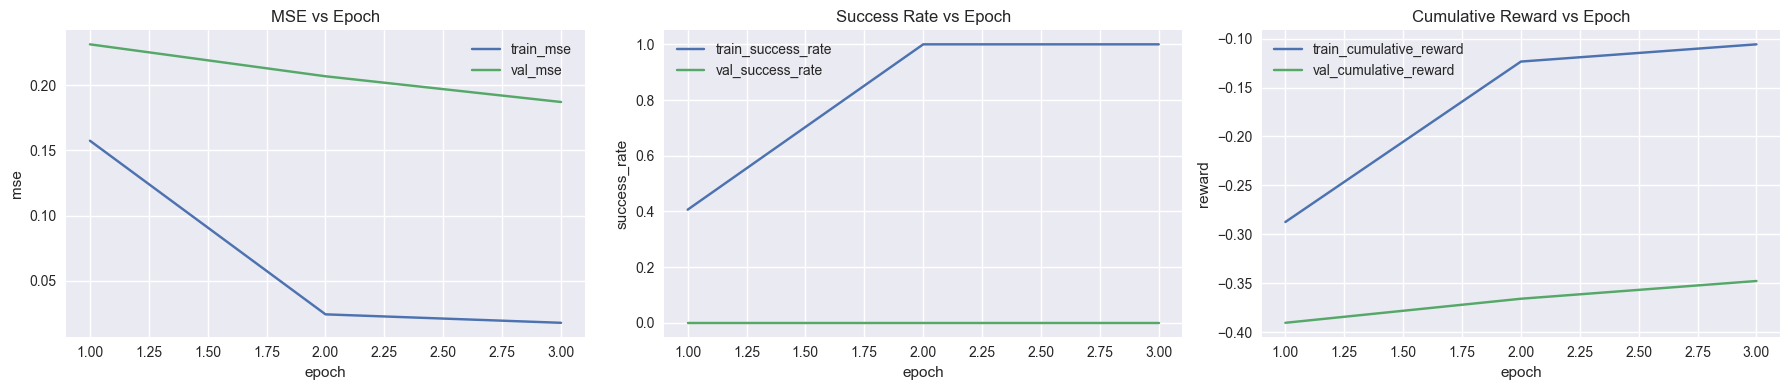

In [3]:
result_dirs = discover_result_dirs()
print(f"发现结果目录数量: {len(result_dirs)}")

if not result_dirs:
    print("[INFO] 尚未发现 results 目录下的实验产物，请先运行训练。")
else:
    latest_dir = result_dirs[-1]
    metrics_path = latest_dir / "metrics.csv"
    metrics_df = safe_read_csv(metrics_path)

    if metrics_df is None or metrics_df.empty:
        print(f"[INFO] 未读取到有效 metrics.csv: {metrics_path}")
    else:
        print(f"使用最新实验目录: {latest_dir}")
        display(metrics_df.tail(5))

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        axes[0].plot(metrics_df["epoch"], metrics_df["train_mse"], label="train_mse")
        axes[0].plot(metrics_df["epoch"], metrics_df["val_mse"], label="val_mse")
        axes[0].set_title("MSE vs Epoch")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("mse")
        axes[0].legend()

        axes[1].plot(metrics_df["epoch"], metrics_df["train_success_rate"], label="train_success_rate")
        axes[1].plot(metrics_df["epoch"], metrics_df["val_success_rate"], label="val_success_rate")
        axes[1].set_title("Success Rate vs Epoch")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel("success_rate")
        axes[1].legend()

        axes[2].plot(metrics_df["epoch"], metrics_df["train_cumulative_reward"], label="train_cumulative_reward")
        axes[2].plot(metrics_df["epoch"], metrics_df["val_cumulative_reward"], label="val_cumulative_reward")
        axes[2].set_title("Cumulative Reward vs Epoch")
        axes[2].set_xlabel("epoch")
        axes[2].set_ylabel("reward")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

## 实验总览（summary.json 聚合）

In [4]:
exp_df = build_experiment_table()

if exp_df.empty:
    print("[INFO] 未发现可聚合的 summary.json。")
else:
    ordered_cols = [
        "exp_name",
        "epochs",
        "final_val_success_rate",
        "final_val_mse",
        "final_val_cumulative_reward",
        "total_training_time_sec",
        "train_dataset_size",
        "val_dataset_size",
    ]
    existing_cols = [c for c in ordered_cols if c in exp_df.columns]
    leaderboard = exp_df.sort_values(
        by=["final_val_success_rate", "final_val_mse"],
        ascending=[False, True],
        na_position="last",
    )
    print("实验对比（按 val_success_rate 降序 + val_mse 升序）")
    display(leaderboard[existing_cols])

实验对比（按 val_success_rate 降序 + val_mse 升序）


,exp_name,epochs,final_val_success_rate,final_val_mse,final_val_cumulative_reward,total_training_time_sec,train_dataset_size,val_dataset_size
0,full_baseline_synthetic_smoke,3,0.0,0.18719,-0.34763,0.551871,512,128


## 配置-结果联动（resolved_config.yaml + summary）

In [5]:
if exp_df.empty:
    print("[INFO] 无实验数据，跳过配置敏感性分析。")
else:
    candidate_params = [
        "sequence_length",
        "stride",
        "noise_std",
        "hidden_dim",
        "num_layers",
        "num_heads",
        "learning_rate",
        "batch_size",
    ]

    numeric_cols = [
        c for c in candidate_params + ["final_val_mse", "final_val_success_rate", "final_val_cumulative_reward"]
        if c in exp_df.columns
    ]

    # 数值化处理，尽量避免由于类型问题导致相关性计算失败
    corr_df = exp_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    if corr_df.dropna(axis=1, how="all").shape[1] < 2:
        print("[INFO] 数值字段不足，无法计算相关性。")
    else:
        corr = corr_df.corr(numeric_only=True)
        target_cols = [c for c in ["final_val_success_rate", "final_val_mse", "final_val_cumulative_reward"] if c in corr.columns]
        if not target_cols:
            print("[INFO] 缺少目标指标列，无法做配置联动分析。")
        else:
            print("超参数与目标指标相关性（皮尔逊）")
            display(corr[target_cols].sort_index())

超参数与目标指标相关性（皮尔逊）


,final_val_success_rate,final_val_mse,final_val_cumulative_reward
batch_size,NaN,NaN,NaN
final_val_cumulative_reward,NaN,NaN,NaN
final_val_mse,NaN,NaN,NaN
final_val_success_rate,NaN,NaN,NaN
hidden_dim,NaN,NaN,NaN
learning_rate,NaN,NaN,NaN
noise_std,NaN,NaN,NaN
num_heads,NaN,NaN,NaN
num_layers,NaN,NaN,NaN
sequence_length,NaN,NaN,NaN


## ManiSkill `.npz` 数据健康检查

In [6]:
demo_path = as_path(DEMO_NPZ_PATH)

if demo_path is None:
    print("[INFO] DEMO_NPZ_PATH 为空，跳过 ManiSkill npz 检查。")
elif not demo_path.exists():
    print(f"[INFO] 指定 npz 不存在: {demo_path}")
else:
    try:
        demo_data = np.load(demo_path)
        print(f"加载成功: {demo_path}")
        print(f"keys: {list(demo_data.keys())}")

        obs_key = "observations" if "observations" in demo_data else None
        action_key = "actions" if "actions" in demo_data else None

        if obs_key is None or action_key is None:
            print("[WARN] 缺少 observations/actions 字段，无法进行标准健康检查。")
        else:
            obs = demo_data[obs_key]
            actions = demo_data[action_key]

            if obs.ndim == 2:
                obs = obs[None, ...]
            if actions.ndim == 2:
                actions = actions[None, ...]

            print(f"obs_shape = {obs.shape}")
            print(f"action_shape = {actions.shape}")

            episode_count = int(obs.shape[0])
            episode_len = int(obs.shape[1])
            obs_dim = int(obs.shape[-1])
            action_dim = int(actions.shape[-1])

            finite_ratio_obs = float(np.isfinite(obs).mean())
            finite_ratio_actions = float(np.isfinite(actions).mean())
            abs_action_p99 = float(np.nanpercentile(np.abs(actions), 99))

            print("\n数据健康统计:")
            print(f"- episode_count: {episode_count}")
            print(f"- episode_length: {episode_len}")
            print(f"- obs_dim/action_dim: {obs_dim}/{action_dim}")
            print(f"- finite_ratio_obs: {finite_ratio_obs:.6f}")
            print(f"- finite_ratio_actions: {finite_ratio_actions:.6f}")
            print(f"- abs_action_p99: {abs_action_p99:.6f}")

            if obs.shape[:2] != actions.shape[:2]:
                print("[WARN] observations/actions 在 episode 或时间维度不一致。")

            # 长度分布：如果是 [E, T, D] 规则张量，长度分布退化为常数；仍输出用于占位
            lengths = np.full((episode_count,), episode_len)
            plt.figure(figsize=(6, 4))
            plt.hist(lengths, bins=min(20, max(1, episode_count // 2)))
            plt.title("Episode Length Distribution")
            plt.xlabel("length")
            plt.ylabel("count")
            plt.show()
    except Exception as exc:
        print(f"[WARN] 读取或分析 npz 失败: {exc}")

[INFO] DEMO_NPZ_PATH 为空，跳过 ManiSkill npz 检查。


## 自动结论与下一步建议

In [7]:
if exp_df.empty:
    print("当前没有可用实验结果。")
    print("下一步建议: 先运行 train.py 生成至少一个 results/* 实验目录。")
else:
    best = pick_best_experiment(exp_df)
    print("当前最佳实验（按 success_rate 优先，其次 val_mse）")
    display(best.to_frame("value"))

    print("\n下一步建议:")
    print("1) 在同一数据设置下做 2-3 组 learning_rate 与 hidden_dim 网格对比")
    print("2) 固定模型后再调 sequence_length/stride，观察 val_success_rate 波动")
    print("3) 接入真实 ManiSkill npz 后，优先检查 finite_ratio 与维度一致性")

当前最佳实验（按 success_rate 优先，其次 val_mse）


,value
exp_name,full_baseline_synthetic_smoke
exp_dir,/Users/kiki/Documents/Codex/2026-04-22-files-m...
epochs,3
train_dataset_size,512
val_dataset_size,128
total_training_time_sec,0.551871
final_train_mse,0.017845
final_val_mse,0.18719
final_val_success_rate,0.0
final_val_cumulative_reward,-0.34763



下一步建议:
1) 在同一数据设置下做 2-3 组 learning_rate 与 hidden_dim 网格对比
2) 固定模型后再调 sequence_length/stride，观察 val_success_rate 波动
3) 接入真实 ManiSkill npz 后，优先检查 finite_ratio 与维度一致性


In [8]:
import gymnasium as gym
import mani_skill.envs

env = gym.make("PickCube-v1", obs_mode="state", render_mode="rgb_array")
obs, info = env.reset(seed=0)

for _ in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()

print("Mac test passed: simulation loop runs.")
env.close()

/Users/kiki/Documents/Codex/2026-04-22-files-mentioned-by-the-user-proposal/full_baseline_project/.conda-ms3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/kiki/Documents/Codex/2026-04-22-files-mentioned-by-the-user-proposal/full_baseline_project/.conda-ms3/lib/python3.11/site-packages/sapien/_vulkan_tricks.py:63: UserWarning: Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.
  warn("Failed to find system libvulkan. Fallback to SAPIEN builtin libvulkan.")
/Users/kiki/Documents/Codex/2026-04-22-files-mentioned-by-the-user-proposal/full_baseline_project/.conda-ms3/lib/python3.11/site-packages/sapien/wrapper/pinocchio_model.py:299: UserWarning: pinnochio package is not installed, robotics functionalities will not be available
  warnings.warn(
2026-04-23 09:57:37,839 - mani_skil

Enabled instance extension VK_KHR_get_physical_device_properties2 is not present at instance level.
Enabled instance extension VK_KHR_get_physical_device_properties2 is not present at instance level.


RuntimeError: vk::createInstanceUnique: ErrorIncompatibleDriver